# ЛАБА 3

Загрузка библиотек

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from skopt import BayesSearchCV

# Загрузка датасета

In [2]:
df = pd.read_csv(r'backpack.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    300000 non-null  int64  
 1   Brand                 290295 non-null  str    
 2   Material              291653 non-null  str    
 3   Size                  293405 non-null  str    
 4   Compartments          300000 non-null  float64
 5   Laptop Compartment    292556 non-null  str    
 6   Waterproof            292950 non-null  str    
 7   Style                 292030 non-null  str    
 8   Color                 290050 non-null  str    
 9   Weight Capacity (kg)  299862 non-null  float64
 10  Price                 300000 non-null  float64
dtypes: float64(3), int64(1), str(7)
memory usage: 25.2 MB


In [3]:
df.head()

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312


Удаляю дубликаты

In [4]:
df = df.drop_duplicates()

Проверяю есть ли пропуски

In [5]:
df.isnull().sum()

id                         0
Brand                   9705
Material                8347
Size                    6595
Compartments               0
Laptop Compartment      7444
Waterproof              7050
Style                   7970
Color                   9950
Weight Capacity (kg)     138
Price                      0
dtype: int64

# Заполняю пропуски 

In [6]:
cat_cols = ['Brand', 'Material', 'Size', 'Laptop Compartment', 'Waterproof', 'Style', 'Color']

for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

In [7]:
df['Weight Capacity (kg)'] = df['Weight Capacity (kg)'].fillna(df['Weight Capacity (kg)'].median())

In [8]:
df.isnull().sum()

id                      0
Brand                   0
Material                0
Size                    0
Compartments            0
Laptop Compartment      0
Waterproof              0
Style                   0
Color                   0
Weight Capacity (kg)    0
Price                   0
dtype: int64

# Корреляции

<Axes: >

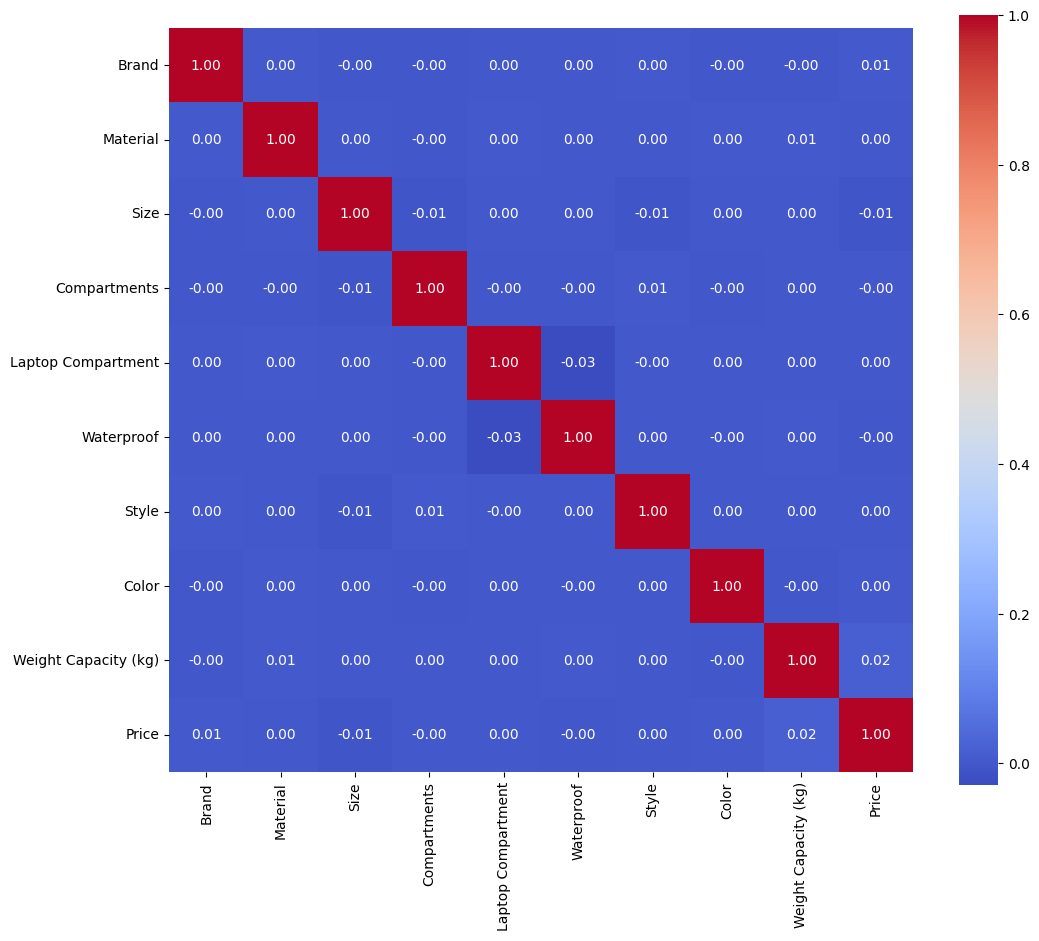

In [18]:
df_corr = df.copy()

from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
df_corr[cat_cols] = encoder.fit_transform(df_corr[cat_cols])

corr_matrix = df_corr.drop('id', axis=1).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)

# Обучени модели

Разделяю данные

In [9]:
# Айди просто убрать он не нужен
X = df.drop(['id', 'Price'], axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Просто CatBoost

In [10]:
from catboost import CatBoostRegressor

for col in cat_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_cols,
    loss_function='MAE',
    verbose=100
)

cb_model.fit(X_train, y_train)

0:	learn: 33.8234358	total: 142ms	remaining: 1m 11s
100:	learn: 33.7353296	total: 8.36s	remaining: 33s
200:	learn: 33.6968836	total: 15.8s	remaining: 23.5s
300:	learn: 33.6717752	total: 23.9s	remaining: 15.8s
400:	learn: 33.6585253	total: 31.2s	remaining: 7.7s
499:	learn: 33.6462933	total: 38.5s	remaining: 0us


CatBoostRegressor(cat_features=['Brand', 'Material', 'Size', 'Laptop Compartment', 'Waterproof', 'Style', 'Color'], depth=6, iterations=500, learning_rate=0.1, loss_function='MAE', verbose=100)

# Поиски гиперпараметров

Поиск по решётке

In [11]:

cb_search_model = CatBoostRegressor(
    iterations=200,
    cat_features=cat_cols,
    loss_function='MAE',
    verbose=False
)

param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1]
}

grid_results = cb_search_model.grid_search(
    param_grid,
    X_train,
    y_train,
    cv=3,
    plot=False
)

print(f"Best Params (Grid): {grid_results['params']}")


bestTest = 33.69156448
bestIteration = 197

0:	loss: 33.6915645	best: 33.6915645 (0)	total: 8.48s	remaining: 42.4s

bestTest = 33.68307453
bestIteration = 198

1:	loss: 33.6830745	best: 33.6830745 (1)	total: 17.6s	remaining: 35.2s

bestTest = 33.6893767
bestIteration = 195

2:	loss: 33.6893767	best: 33.6830745 (1)	total: 28.9s	remaining: 28.9s

bestTest = 33.68339646
bestIteration = 197

3:	loss: 33.6833965	best: 33.6830745 (1)	total: 40.4s	remaining: 20.2s

bestTest = 33.69065727
bestIteration = 194

4:	loss: 33.6906573	best: 33.6830745 (1)	total: 53.2s	remaining: 10.6s

bestTest = 33.67962214
bestIteration = 185

5:	loss: 33.6796221	best: 33.6796221 (5)	total: 1m 10s	remaining: 0us
Estimating final quality...
Training on fold [0/3]

bestTest = 33.7193576
bestIteration = 193

Training on fold [1/3]

bestTest = 33.79536287
bestIteration = 185

Training on fold [2/3]

bestTest = 33.8165105
bestIteration = 195

Best Params (Grid): {'depth': 8, 'learning_rate': 0.1}


Случайный поиск

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

cb_random = CatBoostRegressor(iterations=200, loss_function='MAE', verbose=False, thread_count=-1)

param_dist = {
    'depth': randint(4, 10),
    'learning_rate': uniform(0.01, 0.2),
    'l2_leaf_reg': randint(1, 10)
}

random_search_cb = RandomizedSearchCV(
    estimator=cb_random,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42
)


random_search_cb.fit(X_train, y_train, cat_features=cat_cols)

print(f"Best Random Params: {random_search_cb.best_params_}")

Best Random Params: {'depth': 7, 'l2_leaf_reg': 5, 'learning_rate': np.float64(0.13349630192554332)}


Байесовый подход

In [14]:
from skopt import BayesSearchCV

cb_bayes = CatBoostRegressor(
    iterations=2,
    loss_function='MAE',
    verbose=False,
    thread_count=-1
)

search_spaces_cb = {
    'depth': (4, 10),
    'learning_rate': (0.01, 0.3),
    'l2_leaf_reg': (1, 10)                           #
}

bayes_search_cb = BayesSearchCV(
    estimator=cb_bayes,
    search_spaces=search_spaces_cb,
    n_iter=15,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)

bayes_search_cb.fit(X_train, y_train, cat_features=cat_cols)

print(f"Best Bayes Params: {dict(bayes_search_cb.best_params_)}")

KeyboardInterrupt: 

# Сравнение результатов

In [15]:

cb_final_comparison = {
    'Grid Search ': grid_results['params'],
    'Random Search ': random_search_cb.best_params_,
    'Bayes Search ': bayes_search_cb.best_params_
}

print("\n" + "="*60)
print("СРАВНЕНИЕ ЛУЧШИХ ПАРАМЕТРОВ CATBOOST")
print("="*60)

for method, params in cb_final_comparison.items():
    print(f"\n[{method}]")
    for p, v in params.items():
        print(f"  {p}: {v}")

if 'Grid Search ' in method:
    y_p = cb_search_model.predict(X_test)

if 'Random Search ' in method:
    y_p = random_search_cb.best_estimator_.predict(X_test)

# if 'Bayes Search ' in method:
#     y_p = bayes_search_cb.best_estimator_.predict(X_test)

    print(f"  MAE на тесте: {mean_absolute_error(y_test, y_p):.4f}")


СРАВНЕНИЕ ЛУЧШИХ ПАРАМЕТРОВ CATBOOST

[Grid Search ]
  depth: 8
  learning_rate: 0.1

[Random Search ]
  depth: 7
  l2_leaf_reg: 5
  learning_rate: 0.13349630192554332

[Bayes Search ]
  depth: 6
  l2_leaf_reg: 8
  learning_rate: 0.2805317196658718
